<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/regresja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Regresja Gaussa

In [14]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


/tmp/ipython-input-904907318.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


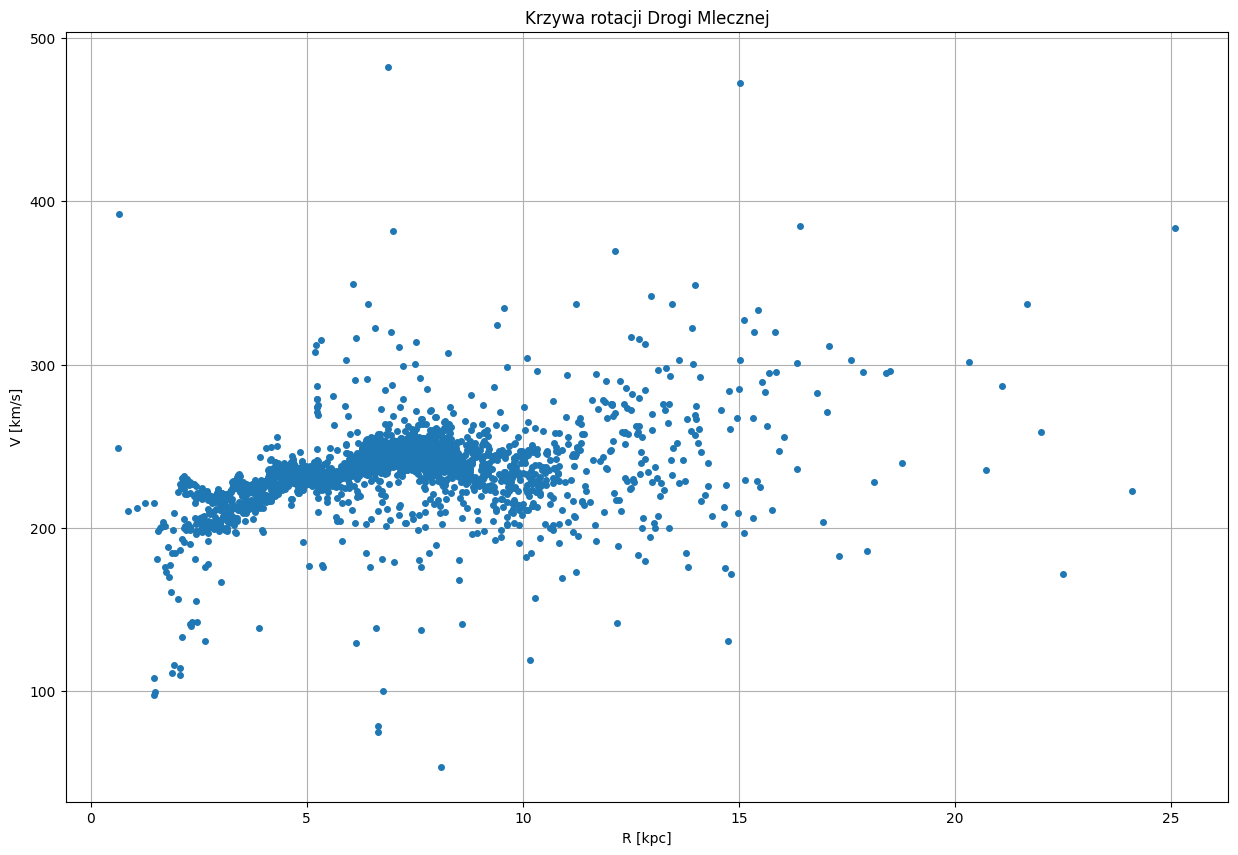

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

Dopasowane parametry: a=254.82, b=15.20, c=22.46


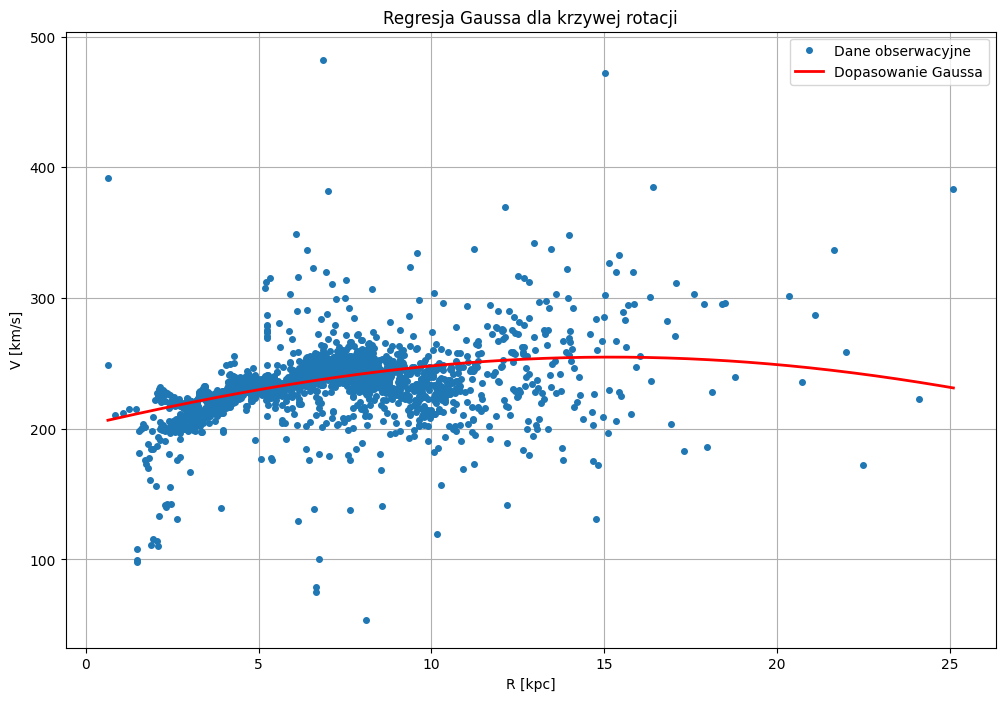

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# definicja funkcji gaussa z wzoru
def gauss(R, a, b, c):
    return a * np.exp(-((R - b)**2) / (2 * c**2))

# dopasowanie modelu do danych
R = df_all["R"].values
V = df_all["V"].values

p0 = [230, 8, 2]  # początkowe parametry: amplituda, środek, szerokość

params, cov = curve_fit(gauss, R, V, p0=p0) # dopasowanie - opis poniżej

a, b, c = params # parametry dopasowania
print(f"Dopasowane parametry: a={a:.2f}, b={b:.2f}, c={c:.2f}")

# dopasowanie R i V do wykresu
R_fit = np.linspace(R.min(), R.max(), 500)
V_fit = gauss(R_fit, *params)

# wykres
plt.figure(figsize=(12,8))
plt.plot(R, V, 'o', markersize=4, label='Dane obserwacyjne')
plt.plot(R_fit, V_fit, 'r-', linewidth=2, label='Dopasowanie Gaussa')
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Regresja Gaussa dla krzywej rotacji")
plt.legend()
plt.grid(True)
plt.show()

curve_fit z scipy.optimize służy do dopasowania dowolnej funkcji matematycznej do danych metodą nieliniowych najmniejszych kwadratów

* funkcja - to funkcja, którą chcesz dopasować, np. gauss(R, a, b, c). Musi przyjmować pierwszy argument jako x (tu R), a kolejne jako parametry dopasowywane (a, b, c).
* xdata, ydata - dane eksperymentalne: xdata - wartości niezależne (promień galaktocentryczny R [kpc]), ydata - wartości zależne (prędkość rotacji V [km/s])
* p0 - initial guess - początkowe przybliżenie parametrów

# Gaussian Process Regression

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# wczytanie danych z kolumnami R, dR, V, dV, source
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip"  # pomijanie złych spacji w kolumnach
)
print(df.head())


         R       dR          V       dV   source
0  2.15841  0.04111  205.50930  8.35472  Fich+89
1  2.29867  0.04378  200.56401  8.35891  Fich+89
2  2.43822  0.04644  196.40036  8.36334  Fich+89
3  2.57704  0.04909  197.61713  8.36801  Fich+89
4  2.71506  0.05171  197.11308  8.37290  Fich+89
